#Day - 1

# IMPORT LIBRARIES

In [ ]:
import numpy as np

In [ ]:
import pandas as pd

# IMPORT DATA

In [ ]:
import csv

In [ ]:
tele = pd.read_csv('telecom_churn_data.csv')           # read the file and display data schema

# Check Data Schema

**Insights which we get from the Data.**

In [ ]:
tele.shape

In [ ]:
type(tele)

In [ ]:
tele.info()             # to display the data types of each column as well as other meta data

In [ ]:
tele.isnull()        # to check null values and gives boolean answers

In [ ]:
tele.isnull().sum()

In [ ]:
tele.isnull().sum().sum()

# Display top 10 rows

In [ ]:
tele.head(10)

# Displaying bottom 10 rows

In [ ]:
tele.tail(10)

# Check column datatype

In [ ]:
df = pd.DataFrame(tele)

In [ ]:
print (df.dtypes)             # data type of the objects

In [ ]:
print (df['last_date_of_month_6'].dtypes)

In [ ]:
print (df['circle_id'].dtypes)

# Add new Dummy column

In [ ]:
df['Dummy_column'] = 0

In [ ]:
df

# Add random/default data

In [ ]:
# add a new column with random value
import random
df['Random_column'] = [random.randint(0, 100) for i in range(len(df))]

In [ ]:
df

# Function

In [ ]:
def telecom():
    tele = pd.read_csv('telecom_churn_data.csv')
    print(tele.info())
    tele.head(10)
    tele.tail(10)
    df = pd.DataFrame(tele)
    print (df.dtypes)


In [ ]:
telecom()

#Day - 2

# Exploring Pandas Profiling

**Pandas-profiling delivers an extended analysis of a DataFrame while alllowing the data analysis to be exported in different formats such as html and json. The package outputs a simple and digested analysis of a dataset.**

In [ ]:
df.describe()                # returns description of the data in DataFrame

In [ ]:
!pip install pandas-profiling

In [ ]:
import pandas as pd
import numpy as np
from pandas_profiling import ProfileReport

In [ ]:
# create report on input dataframe
profile = ProfileReport(df, title='Telecom Report', minimal=True)

In [ ]:
# report output (widgets)
profile.to_widgets()

In [ ]:
# report output (html)
profile.to_file('telecommunicate.html')

# Summary statistics of numerical column

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns        # selecting columns with numerical values only

In [ ]:
numeric_columns

In [ ]:
numeric_df = df[numeric_columns]

In [ ]:
numeric_df

##Mean

In [ ]:
np.mean(numeric_df)

In [ ]:
np.amin(numeric_df)                          # to find the minimum value in the dataframe

In [ ]:
np.amax(numeric_df)                          # to find the maximum value in the dataframe

##Median

In [ ]:
np.median(df['arpu_6'])

In [ ]:
np.max(df['arpu_6'])

In [ ]:
np.min(df['arpu_6'])

In [ ]:
np.mean(df['arpu_6'])

In [ ]:
import statistics

In [ ]:
print("Mode of given data set is %s " %(statistics.mode(tele['arpu_6'])))

##Standard Deviation

In statistics, the standard deviation is a measure of the amount of variation or dispersion of a set of values.
A low standard deviation indicates that the values tend to be close to the mean of the set.
A high standard deviation indicates that the values are spread out over a wider range.

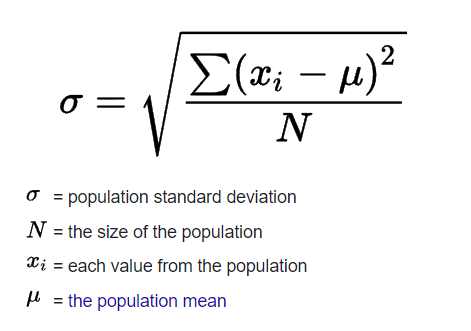

In [ ]:
np.std(df['arpu_6'])               # std - compute standard deviation of the given data

##Mode

In [ ]:
tele.mode(numeric_only=True)

##Percentiles

It is a term which describes how a score is compared to other scores of the same set, on a scale of one hundred.

**It is a value on a scale of one hundred that indicates the percent of a distribution that is equal to or below it.**

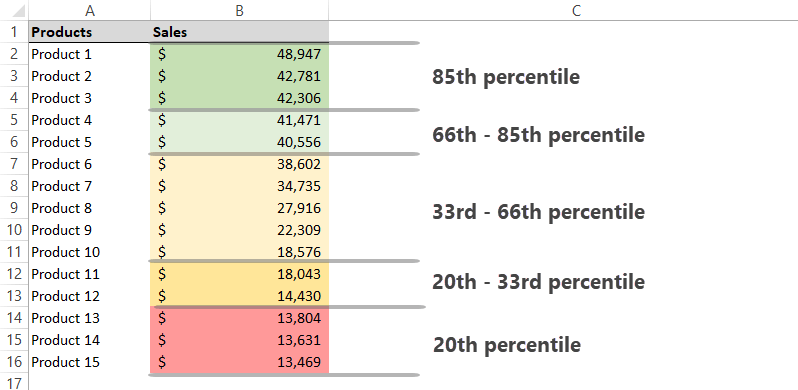

In [ ]:
def percentiles():
    print(np.percentile(df['arpu_6'], 10))
    print(np.percentile(df['arpu_6'], 20))
    print(np.percentile(df['arpu_6'], 40))
    print(np.percentile(df['arpu_6'], 90))
    print(np.percentile(df['arpu_6'], 95))

In [ ]:
percentiles()

##Quantiles

**Quantiles are the set of values/points that divides the dataset into groups of equal size.**

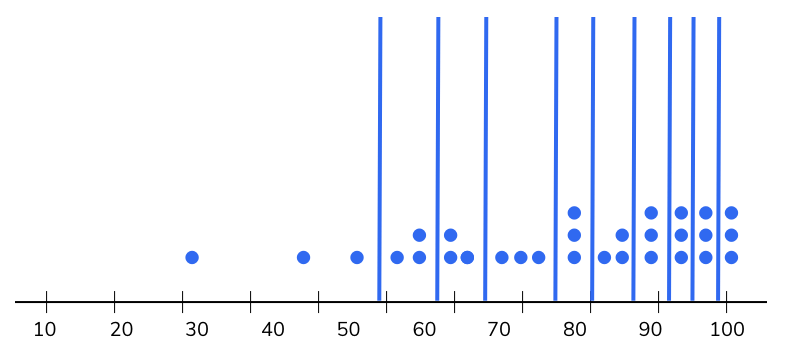

In [ ]:
quantiles = np.quantile(df['arpu_6'], [0.1, 0.25, 0.50, 0.75, 1])

In [ ]:
quantiles

#Cardinality

**The number of unique categories in a variable is called cardinality. For example, the cardinality of the Gender variable, which takes values of female and male, is 2.**

In [ ]:
def cardinality():
    list=[]
    for i in df.columns:
        if df[i].nunique()<10 and df[i].nunique()!=1:
            list.append(i)
    print(list)

In [ ]:
cardinality()

In [ ]:
df['fb_user_6'].value_counts()

In [ ]:
df['night_pck_user_6'].value_counts()

#Drop unwanted column

In [ ]:
new_df = numeric_df.drop('mobile_number',axis=1)

In [ ]:
new_df

#Part - 3

#Null values in column

Null values present various problems :  

1.   It can lead to a lack of precision in the statistical analysis.
2.   Ends up building a biased machine learning model which will lead to incorrect results if not handled properly.

In [ ]:
new_df.isnull().sum()

In [ ]:
new_df.isnull().sum().sum()

#Replace null values as per analysis

In [ ]:
new_df.fillna(new_df.median(), inplace= True)

In [ ]:
new_df

In [ ]:
df1 = new_df

In [ ]:
# to fill the missing value within the range
df1.interpolate(inplace=True)

In [ ]:
df1

In [ ]:
df1.aon.interpolate(inplace=True)

In [ ]:
df1

# Outlier

**Outlier is a data point or data points which is very different from the average value.**

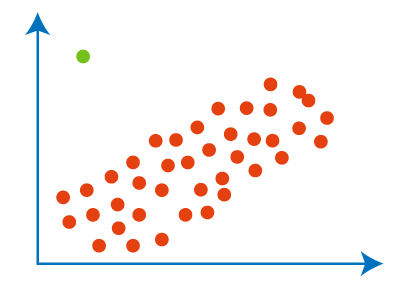

**Could happen due to :**

1.   Error in collection of data/transmission of data.
2.   Valid but unusual



#Finding outlier - IQR Technique

**IQR is used to measure variability by dividing a data set into quartiles. The data is split into 4 equal parts.**

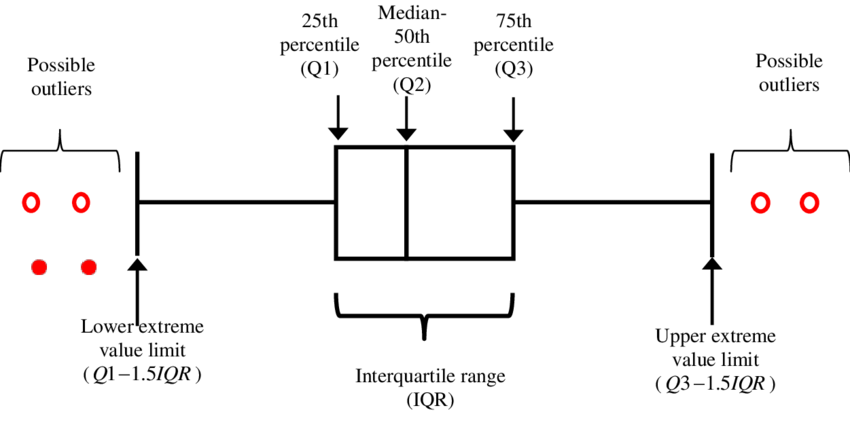

In [ ]:
data=[int(x) for x in new_df['aon']]

In [ ]:
q1, q3 = np.percentile(data,[25,75])

In [ ]:
iqr=q3-q1

In [ ]:
lower_bound = q1-(1.5*iqr)
upper_bound = q3+(1.5*iqr)

In [ ]:
upper_bound

In [ ]:
outlier=[]
for data in new_df['aon']:
    if data<lower_bound or data>upper_bound:
        outlier.append(data)

In [ ]:
print("Outlier", outlier)

In [ ]:
# to find the outlier above the upper limit
new_df.aon[new_df['aon'] > upper_bound]

In [ ]:
# to find the outlier below the lower limit
new_df.aon[new_df['aon'] < lower_bound]

In [ ]:
new_df.aon[new_df['aon'] > upper_bound].count()

In [ ]:
new_df.aon[new_df['aon'] < lower_bound].count()

In [ ]:
new_df.shape

**Their are 2 ways to treat outlier :**



1.   Trimming
2.   Capping



In [ ]:
# to clean the outlier, one of the first way is to trim them
trim_aon = new_df[new_df['aon'] < upper_bound]
trim_aon

In [ ]:
# to clean the outlier, one of the other way is to cap them
df["aon"]=np.where(new_df["aon"]>upper_bound,upper_bound,np.where(new_df["aon"]<lower_bound,lower_bound,new_df["aon"]))
df["aon"]

#Finding Outlier with Z-score

**Z-score is a statistical measurement that describes a value's relationship to the mean of a group of values.**

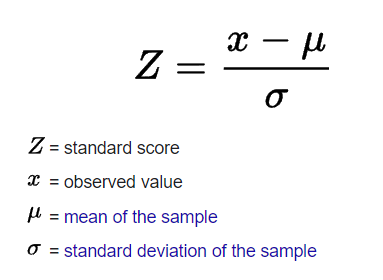

**Any data point beyond +- 3 std is treated as outlier.**

**If a Z-score is 0, it indicates that the data point's score is identical to the mean score.**

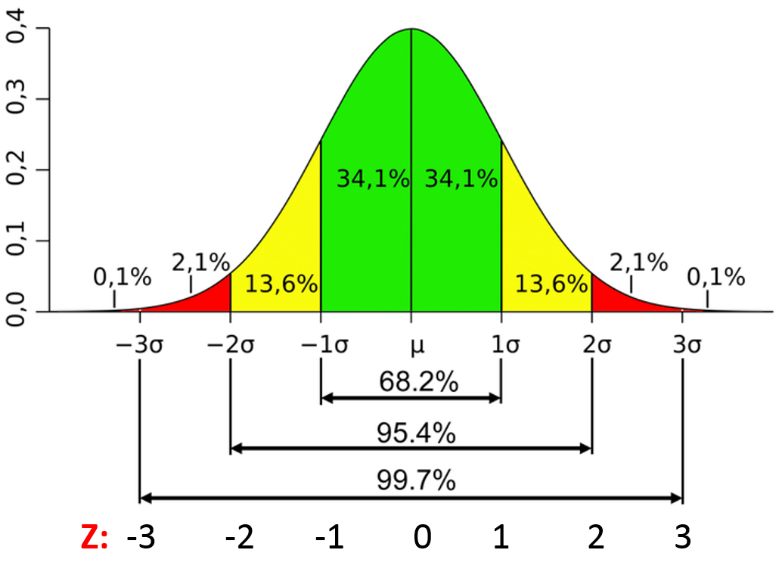

In [ ]:
import scipy.stats as stats                      # scipy : scientific computation library that uses NumPy
z_score = stats.zscore(new_df)                   # z-score : number of standard deviations from the mean value
print(z_score)

In [ ]:
x = new_df['aon']
mean = sum(x)/len(x)
diff = [(x-mean)**2 for value in x]
sum_of_diff = sum(diff)
std = (sum_of_diff/ (len(x)-1))**0.5
print(std)

In [ ]:
zscore = [(value-mean) / std for value in x]
print(zscore)

In [ ]:
z = np.abs(new_df.apply(lambda x:(x-np.mean(x)) / np.std(x)))

In [ ]:
outlier = np.where(z>3)

In [ ]:
print(new_df.iloc[outlier])

#Finding outlier with quantile/percentile

In [ ]:
min_threshold = new_df['arpu_6'].quantile(0.95)
min_threshold

In [ ]:
max_threshold = new_df['arpu_6'].quantile(0.05)
max_threshold

In [ ]:
# outliers
new_df.arpu_6[(new_df.arpu_6 > min_threshold) | (new_df.arpu_6 < max_threshold)]

In [ ]:
# good looking data - without outliers
new_df.arpu_6[(new_df.arpu_6 < min_threshold) & (new_df.arpu_6 > max_threshold)]

# Box plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.boxplot(new_df.aon)
plt.show()

In [ ]:
plt.boxplot(trim_aon.aon)
plt.show()

In [ ]:
plt.subplot(2,2,2)              # takes 3 argument that describes the layout of figure
sns.boxplot(data = new_df['aon'])

In [ ]:
plt.subplot(2,2,2)
sns.boxplot(data = trim_aon['aon'])

# Part - 4

**Univariate & Bivariate analysis**

Univariate analysis - analysis of 1 variable.         
Technique : Statistics, Box plot

Bivariate analysis - analysis of 2 variable.        
Technique : Correlation, Scatter plot

In [ ]:
selected_df = new_df[['arpu_6', 'arpu_7','arpu_8','arpu_9','onnet_mou_6','onnet_mou_7','onnet_mou_8','onnet_mou_9','aon']]
selected_df

##Covariance

**Covariance is a measure of the relationship between two random variables and to what extent, they change together.**

Compares 2 data sets and tells that if they are similar then how much similar they are.

In [ ]:
selected_df.cov()

##Correlation matrix

**Correlation**

It compared 2 data sets and tells whether they are same or different.

Their are 3 types of correlation :

1.   +1 (positively correlated)
2.     0 (No correlation)
3.   -1 (negatively correlated)



In [ ]:
selected_df.corr()

In [ ]:
# without using pre-defined function with 2 variable

A = new_df['aon'].to_numpy()
B = new_df['arpu_6'].to_numpy()
corr_matrix1 = np.corrcoef(A,B)
print(corr_matrix1)

In [ ]:
# without using pre-defined function with multiple variables in selected_df

corr_matrix2 = [[0]*len(selected_df.columns) for x in range(len(selected_df.columns))]

In [ ]:
for i in range(len(selected_df.columns)):
    for j in range(len(selected_df.columns)):
        corr_matrix2[i][j] = sum((selected_df[selected_df.columns[i]] - selected_df[selected_df.columns[i]].mean()) * (selected_df[selected_df.columns[j]] - selected_df[selected_df.columns[j]].mean()))/((len(selected_df)-1 * selected_df[selected_df.columns[i]].std() * selected_df[selected_df.columns[i]].std()))

print(corr_matrix2)

##Importing library

In [ ]:
import scipy.stats

##Co-efficient of Correlation

It is the number which holds the strength & direction of relation.

Their are 3 ways to find correlation coefficient :

1.   Pearson's correlation
2.   Spearman's correlation
3.   Kendall's correlation



##Pearson's correlation

The Pearson correlation coefficient (r) is the most common way of measuring a linear correlation.

In [ ]:
scipy.stats.pearsonr(A, B)    # Pearson's r

In [ ]:
# to find the correlation coefficient with their indices

scipy.stats.pearsonr(A, B)[0]

In [ ]:
# to find the correlation coefficient using dot notation

r, p = scipy.stats.pearsonr(A, B)
r

##Spearman's correlation

It assesses how well the relationship between two variables can be described using a monotonic function.

In [ ]:
scipy.stats.spearmanr(A, B)   # Spearman's rho

In [ ]:
# to find the correlation coefficient with their indices

scipy.stats.spearmanr(A,B)[0]

In [ ]:
# to find the correlation coefficient using dot notation

scipy.stats.spearmanr(A, B).correlation

##Kendall Ranking correlation

Kendall rank correlation is used to test the similarities in the ordering of data when it is ranked by quantities.

In [ ]:
scipy.stats.kendalltau(A, B)  # Kendall's tau

In [ ]:
# to find the correlation coefficient with their indices

scipy.stats.kendalltau(A, B)[0]

In [ ]:
# to find the correlation coefficient using dot notation

scipy.stats.kendalltau(A, B).correlation

##Correlation techniques without predefined function

In [ ]:
my_r = selected_df.corr(method="spearman")
print(my_r)

In [ ]:
import seaborn as sns                          # For pairplots and heatmaps
import matplotlib.pyplot as plt

In [ ]:
def display_correlation(df):
    r = df.corr(method="spearman")
    plt.figure(figsize=(10,6))
    heatmap = sns.heatmap(df.corr(), vmin=-1,
                      vmax=1, annot=True)
    plt.title("Spearman Correlation")
    return(r)

In [ ]:
display_correlation(selected_df)

In [ ]:
# to use pearson's correlation without the predefined function

pearsoncorr = selected_df.corr(method='pearson')
pearsoncorr

In [ ]:
# to use kendall's correlation without the predefined function

kendall_corr = selected_df.corr(method='kendall')
kendall_corr

#Data Visualization

Pictorial representation of data. One of the best way to present information as it gives insights on trends and relationship.

**Types of Data Visualization :**

1. Histogram : Shows the frequency of data within the given range.


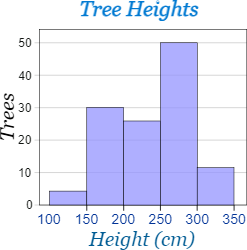

2. Scatter plot : Used to find correlation between 2 variables. Helps identify clusters.


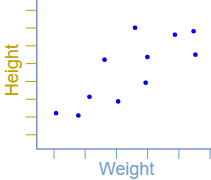

3. Pie chart : A pie chart is a type of graph that represents the data in the circular graph.


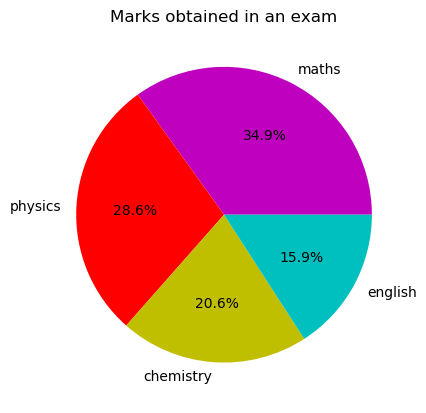

4. Pair plot : It allows us to plot pairwise relationships between variables within a dataset.


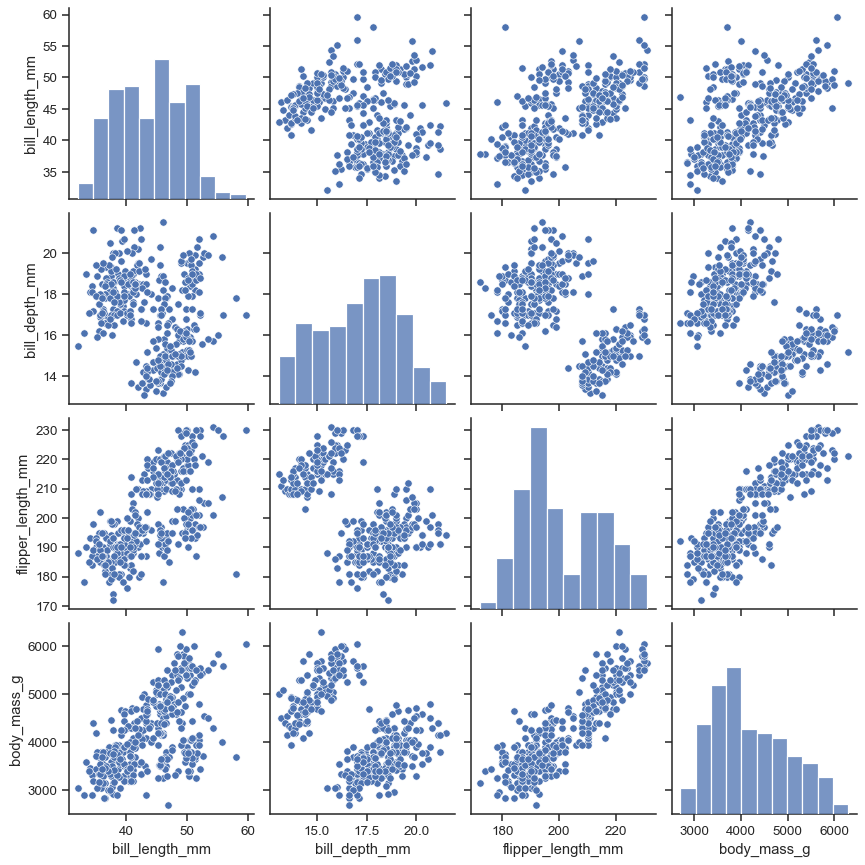

5. Bar plot : It is a graph that represents the category of data with rectangular bars with lengths and heights that is proportional to the values which they represent. The bar plots can be plotted horizontally or vertically.


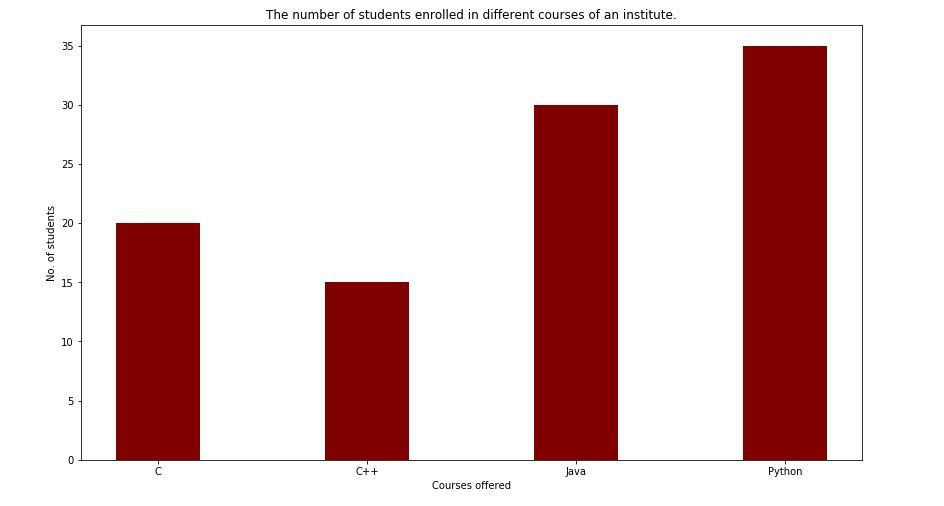

6. Line plot : It is a type of chart which displays information as a series of data points called 'markers' connected by straight line segments. Helps to identify trends.



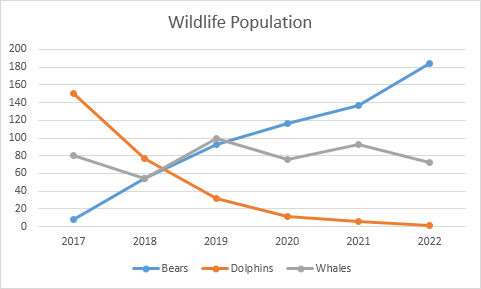

#Window function

Functions where the input values are taken from a “window” of one or more rows in a series or a table and calculation is performed over them. The word window means the number of rows between the two boundaries by which we perform calculations including the boundary rows.

## Rolling mean

“Rolling”, which means sliding in a sense, Rolling windows operations means applying some formula to a range of rows by sliding with that fixed number, from the initial value all the way to the final value.

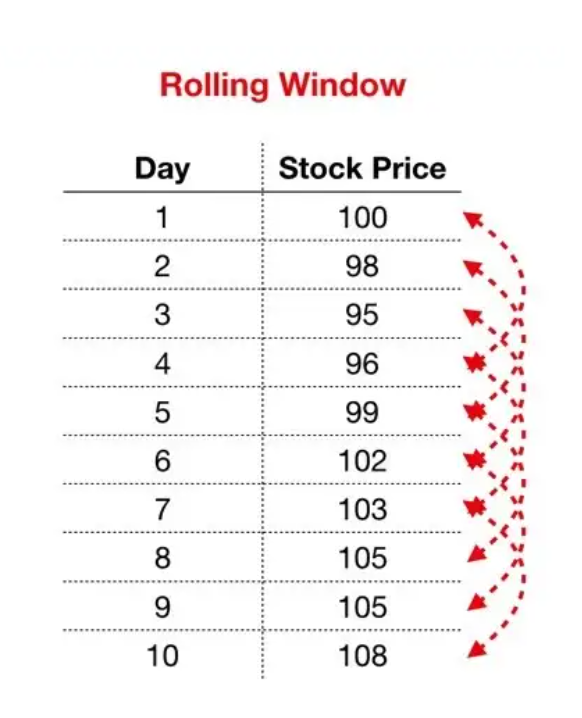

In [ ]:
import pandas as pd
df = pd.read_csv('telecom_churn_data1.csv')

In [ ]:
window_df = df[['mobile_number', 'POC_circle','circle_region']]
window_df

In [ ]:
target_col_df = pd.to_numeric(window_df["POC_circle"])
window_df['POC_circle_mean'] = target_col_df.rolling(window=2).mean()
window_df.head(10)

##Sum function with circle_region column

In [ ]:
g = window_df.groupby("circle_region")

In [ ]:
g.get_group('inner_circle')

In [ ]:
g.get_group('inner_circle').rolling(2).sum().head(5)

In [ ]:
g.get_group('outer_circle').rolling(2).sum().head(5)

In [ ]:
g.get_group('outer_circle').rolling(2).mean().head(5)

In [ ]:
g.get_group('inner_circle').rolling(2).mean().head(5)

#Transpose and Pivot tables

In [ ]:
import pandas as pd
import csv

In [ ]:
import numpy as np

In [ ]:
df = pd.read_csv("telecom_churn_data11.csv")

##1) Impute dates as 1st of that month for variables "date_of_last_rech_6", _7, _8, _9 for null values.

In [ ]:
date=df[["date_of_last_rech_6","date_of_last_rech_7","date_of_last_rech_8","date_of_last_rech_9"]]
date

In [ ]:
date.fillna({"date_of_last_rech_6":"6/01/2014","date_of_last_rech_7":"7/01/2014","date_of_last_rech_8":"8/01/2014","date_of_last_rech_":"9/01/2014"},inplace=True)

In [ ]:
date

##2) Impute dates as 1st of that month for variables "date_of_last_rech_data_6", _7, _8, _9 for null values.

In [ ]:
date_data = df[["date_of_last_rech_data_6","date_of_last_rech_data_7","date_of_last_rech_data_8","date_of_last_rech_data_9"]]
date_data

In [ ]:
date_data.fillna({"date_of_last_rech_data_6":"6/01/2014","date_of_last_rech_data_7":"7/01/2014","date_of_last_rech_data_8":"8/01/2014","date_of_last_rech_data_9":"9/01/2014"},inplace=True)

In [ ]:
date_data

##3) a) Amount of recharge circle wise, for month 6-7-8-9

In [ ]:
pd.pivot_table?             # gives descrption on pivot table parameters

In [ ]:
df1 = df[['circle_region','total_rech_amt_6','total_rech_amt_7','total_rech_amt_8','total_rech_amt_9']]
df1

In [ ]:
table = pd.pivot_table(df1,index=["circle_region"],aggfunc=np.sum)
table

Another way, by using groupby

In [ ]:
g = df1.groupby("circle_region")
g.get_group('inner_circle').sum()

In [ ]:
g = df1.groupby("circle_region")
g.get_group('outer_circle').sum()

##3) b) Amount of data recharge circle wise, for month 6-7-8-9

In [ ]:
g = df1.groupby("circle_region")
g.get_group('inner_circle').mean()

In [ ]:
g = df1.groupby("circle_region")
g.get_group('outer_circle').mean()

##3) c) Avg recharge for circle + month wise i.e., 6-7-8-9

In [ ]:
df2 = df[['circle_region','total_rech_num_6','total_rech_num_7','total_rech_num_8','total_rech_num_9']]
df2

##3) d) Avg data recharge for circle + month wise i.e., 6-7-8-9

In [ ]:
g = df2.groupby("circle_region")
g.get_group('inner_circle').sum()

In [ ]:
g = df2.groupby("circle_region")
g.get_group('inner_circle').mean()

In [ ]:
g = df2.groupby("circle_region")
g.get_group('outer_circle').sum()

In [ ]:
g = df2.groupby("circle_region")
g.get_group('outer_circle').mean()

##4) a)  Total amount of recharge (all 4 months), circle-wise

In [ ]:
pd.pivot_table(df1,index=["circle_region"],aggfunc=np.sum, margins=True, margins_name='Total').reset_index()

##4) b) Avg of amount of data recharge (all 4 months), circle-wise

In [ ]:
pd.pivot_table(df2,index=["circle_region"],aggfunc=np.mean, margins=True, margins_name='Mean').reset_index()

In [ ]:
df['total_rech_num_6'].isnull().sum()

#Cluster Analysis

##Euclidean distance

In either the plane or 3-dimensional space measures the length of a segment connecting the two points.

In [ ]:
from scipy.spatial.distance import euclidean

In [ ]:
data1 = list(df['arpu_6'])
data2 = list(df['arpu_7'])

In [ ]:
# finding euclidean distance for arpu_6, arpu_7, arpu_8, arpu_9
euclidean(data1, data2)

Another method for Euclidean distance (without built-in library)

In [ ]:
from math import *

def euclidean_distance(x,y):
    return sqrt(sum(pow(a-b,2) for a, b in zip(x, y)))

In [ ]:
euclidean_distance(data1, data2)

In [ ]:
euclidean(list(df['arpu_7']), list(df['arpu_8']))

In [ ]:
euclidean(list(df['arpu_8']), list(df['arpu_9']))

In [ ]:
euclidean(list(df['arpu_9']), list(df['arpu_6']))

##Manhattan distance

In [ ]:
m1 = list(df['total_rech_amt_6'])
m2 = list(df['total_rech_amt_7'])

In [ ]:
# by using built-in function

from scipy.spatial.distance import cityblock
cityblock(m1,m2)

In [ ]:
# without using built-in function  ## import maths library

def manhattan_distance(x,y):
    return sum(abs(a-b) for a,b in zip(x,y))

In [ ]:
manhattan_distance(m1,m2)

In [ ]:
cityblock(list(df['total_rech_amt_8']), list(df['total_rech_amt_9']))

##Cosine similarity

In [ ]:
import math
import re
from collections import Counter

In [ ]:
WORD = re.compile(r"\w+")

In [ ]:
def get_cosine(vec1, vec2):
    intersection = set(vec1.keys()) & set(vec2.keys())
    numerator = sum([vec1[x] * vec2[x] for x in intersection])
    sum1 = sum([vec1[x] **2 for x in list(vec1.keys())])
    sum2 = sum([vec2[x] **2 for x in list(vec2.keys())])
    denominator = math.sqrt(sum1) * math.sqrt(sum2)
    if not denominator:
        return 0.0
    else:
        return float(numerator)/denominator

In [ ]:
def text_to_vector(text):
    words = WORD.findall(text)
    return Counter(words)

In [ ]:
text1 = "Not reachable at the moment"
text2 = "Not reachable due to network issues"

In [ ]:
v1 = text_to_vector(text1)
v2 = text_to_vector(text2)

In [ ]:
get_cosine(v1,v2)

Another method of text similarity

In [ ]:
from difflib import SequenceMatcher
sm = SequenceMatcher
sm(None,'telecommunication','communication').ratio()

In [ ]:
sm(None,"Not reachable at the moment","Not reachable due to network issues").ratio()

Built-in method

In [ ]:
from sklearn.feature_extraction .text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

para=['Not reachable at the moment','Not reachable due to network issues']
vectorizer=TfidfVectorizer()
tfidf_matrix=vectorizer.fit_transform(para)
cosine_similarities=cosine_similarity(tfidf_matrix)
cosine_similarities

##Levenshtein distance

In [ ]:
!pip install pyenchant

In [ ]:
import enchant

In [ ]:
enchant.utils.levenshtein("Network","Networking")    # 3 because string 1 can be string 2 by inserting 'i','n','g'

In [ ]:
enchant.utils.levenshtein("telecom","telephone")

In [ ]:
enchant.utils.levenshtein("incoming","outgoing")

In [ ]:
enchant.utils.levenshtein("Offline","Online")

In [ ]:
enchant.utils.levenshtein("recharge amount","data recharge amount")

In [ ]:
enchant.utils.levenshtein("3G user","2G user")

In [ ]:
enchant.utils.levenshtein("Communication","Telecommunication")

In [ ]:
enchant.utils.levenshtein("communication","Telecommunication")        # even the case matters here

In [ ]:
enchant.utils.levenshtein("recharge plan will expire","data plan will expire in 2 days")

#Cluster Analysis / Customer Segmentation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cdf = df[['onnet_mou_6','onnet_mou_7','onnet_mou_8','onnet_mou_9','offnet_mou_6','offnet_mou_7','offnet_mou_8','offnet_mou_9']]

In [ ]:
cdf

In [ ]:
print('Missing value ratio in column is:\n')
print(cdf.isna().sum()/len(cdf)*100)

In [ ]:
cdf.fillna(cdf.median(), inplace= True)

In [ ]:
print('Missing value ratio in column is:\n')
print(cdf.isna().sum()/len(cdf)*100)

In [ ]:
from sklearn.preprocessing import StandardScaler

#create scaled DataFrame where each variable has mean of 0 and standard dev of 1 for standardizing data
scaled_df = StandardScaler().fit_transform(cdf)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
KMeans(init='random', n_clusters=8, n_init=10, random_state=None)

In [ ]:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 10,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

#visualize results
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
kmean_model = KMeans(n_clusters=5, init='k-means++',random_state=0)

In [ ]:
y_kmeans = kmean_model.fit_predict(cdf)

In [ ]:
cdf[:10].plot(kind='bar')
plt.title('Clusters of Customers')
plt.xlabel('Amount of using same network')
plt.ylabel('Amount of using other network')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# creating the dataset
data = {'C':20, 'C++':15, 'Java':30,
		'Python':35}
courses = list(data.keys())
values = list(data.values())

fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.bar(courses, values, color ='maroon',
		width = 0.4)

plt.xlabel("Courses offered")
plt.ylabel("No. of students enrolled")
plt.title("Students enrolled in different courses")
plt.show()


In [ ]:
courses = list(cdf.onnet_mou_6)
values = list(cdf.offnet_mou_6)

In [ ]:
plt.bar(courses, values, color ='maroon', width = 0.9, label='Customer 1')
plt.bar(cdf.onnet_mou_7, cdf.offnet_mou_7, color ='blue', width = 0.9, label='Customer 2')
plt.bar(cdf.onnet_mou_8, cdf.offnet_mou_8, color ='red', width = 0.9, label='Customer 3')
plt.bar(cdf.onnet_mou_9, cdf.offnet_mou_9, color ='yellow', width = 0.9, label='Customer 4')
plt.title('Clusters of Customers')
plt.xlabel('Amount of using same network')
plt.ylabel('Amount of using other network')
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(5)
kmeans.fit(cdf)

In [ ]:
identified_clusters = kmeans.fit_predict(cdf)
identified_clusters

In [ ]:
data_with_clusters = df.copy()
data_with_clusters['Clusters'] = identified_clusters
plt.scatter(data_with_clusters['offnet_mou_6'],data_with_clusters['onnet_mou_6'],c=data_with_clusters['Clusters'],cmap='rainbow')

In [ ]:
x = df[['sachet_3g_9','monthly_2g_9','arpu_2g_9','vol_3g_mb_8','vol_3g_mb_9','vol_2g_mb_8','vol_2g_mb_9','av_rech_amt_data_9','count_rech_3g_9','max_rech_data_9','total_rech_amt_8','total_rech_amt_9','max_rech_amt_8','max_rech_amt_9','last_day_rch_amt_8']]
